# AT-DJ 02a — Colab Data Prep & Original Feature Catalog

This is the corrected Colab version of old `02a_data_feature_prep.ipynb`. It uses `essentia_newsamp.csv` directly, but **preserves the original feature columns**. It does not collapse the feature set into new labels such as `bpm_label`, `danceability_label`, or `energy_composite`.

Outputs saved for downstream notebooks:
- `df_merged.pkl`: full original dataset
- `feature_catalog.pkl`: selected original-feature catalog
- `feature_prompt.txt`: prompt block with original feature descriptions and observed stats
- `selected_features.json`: selected original feature names

In [ ]:
# This notebook intentionally preserves the original feature columns in essentia_newsamp.csv.
# It does NOT create collapsed/derived labels such as bpm_label, danceability_label, or energy_composite.

from pathlib import Path
import json, pickle, re, time, math, os, warnings
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore', category=FutureWarning)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df_merged = pd.read_csv('drive/MyDrive/GenAI/proj/essentia_newsamp.csv')
print(f'df_merged shape: {df_merged.shape[0]} rows × {df_merged.shape[1]} columns')
print(df_merged.head(2))

df_merged shape: 294 rows × 94 columns
               title         orchestra        singer    year decade    style  \
0  Asi Me Gusta A Mi  Angel D'Agostino  Angel Vargas  1942.0  1940s  milonga   
1       Compadreando  Angel D'Agostino  Angel Vargas  1941.0  1940s  milonga   

   duration_seconds                                  combo_key  \
0            168.95  angel d'agostino | angel vargas | milonga   
1            152.95  angel d'agostino | angel vargas | milonga   

                              album                  filename  ...  \
0  vol-21 la fiesta de buenos aires  27 asi me gusta a mi.mp3  ...   
1  vol-21 la fiesta de buenos aires       28 compadreando.mp3  ...   

   jamendo_happy  jamendo_relaxing  is_danceable  mood_happy  mood_sad  \
0       0.012270          0.006763      0.006534    0.105038  0.822728   
1       0.013921          0.005949      0.060872    0.341053  0.363224   

  mood_relaxed  mood_aggressive  mood_party  mood_acoustic  mood_electronic  
0     0.9

## 1. Validate existing columns

In [ ]:
print('Columns:')
print(list(df_merged.columns))

# These columns are identity/context fields, not engineered feature targets.
METADATA_COLS = ['title', 'orchestra', 'singer', 'year', 'decade', 'style', 'duration_seconds', 'combo_key', 'album', 'filename']
METADATA_COLS = [c for c in METADATA_COLS if c in df_merged.columns]

# Categorical fields that can be described to the LLM but are not scored as numeric ranges.
CATEGORICAL_COLS = ['title', 'orchestra', 'singer', 'style', 'album', 'filename', 'combo_key', 'key', 'scale']
CATEGORICAL_COLS = [c for c in CATEGORICAL_COLS if c in df_merged.columns]

# Numeric original feature columns. We keep them as original columns.
numeric_cols_all = [c for c in df_merged.select_dtypes(include=[np.number]).columns if not c.startswith('Unnamed')]
# Keep year/decade/duration as available context, but focus audio feature EDA on non-identity numeric cols.
AUDIO_NUMERIC_COLS = [c for c in numeric_cols_all if c not in ['year', 'decade']]

print(f'Metadata columns ({len(METADATA_COLS)}): {METADATA_COLS}')
print(f'Categorical/context columns ({len(CATEGORICAL_COLS)}): {CATEGORICAL_COLS}')
print(f'Numeric columns ({len(numeric_cols_all)}): {len(numeric_cols_all)}')
print(f'Audio/context numeric columns for feature handling ({len(AUDIO_NUMERIC_COLS)}): {AUDIO_NUMERIC_COLS}')

Columns:
['title', 'orchestra', 'singer', 'year', 'decade', 'style', 'duration_seconds', 'combo_key', 'album', 'filename', 'duration', 'bpm', 'onset_rate', 'danceability', 'key', 'scale', 'key_strength', 'chords_changes_rate', 'chords_number_rate', 'hpcp_entropy', 'tuning_frequency', 'average_loudness', 'dynamic_complexity', 'spectral_centroid_mean', 'spectral_centroid_stdev', 'spectral_complexity_mean', 'spectral_energy_mean', 'spectral_rolloff_mean', 'spectral_flux_mean', 'dissonance_mean', 'zerocrossingrate_mean', 'mirex_mood_passionate_rousing_confident_boisterous_rowdy', 'mirex_mood_rollicking_cheerful_fun_sweet_amiable_good_natured', 'mirex_mood_literate_poignant_wistful_bittersweet_autumnal_brooding', 'mirex_mood_humorous_silly_campy_quirky_whimsical_witty_wry', 'mirex_mood_aggressive_fiery_tense_anxious_intense_volatile_visceral', 'jamendo_alternative', 'jamendo_ambient', 'jamendo_atmospheric', 'jamendo_chillout', 'jamendo_classical', 'jamendo_dance', 'jamendo_downtempo', 'jame

## 2. Feature EDA over original columns

Original numeric features considered: 83
Top 20 by scaled variance:
mirex_mood_literate_poignant_wistful_bittersweet_autumnal_brooding    0.053903
average_loudness                                                      0.051906
mood_sad                                                              0.050899
tuning_frequency                                                      0.049695
mood_relaxed                                                          0.044847
jamendo_classical                                                     0.044545
duration_seconds                                                      0.040331
duration                                                              0.040161
jamendo_pop                                                           0.040005
mood_happy                                                            0.039003
chords_number_rate                                                    0.037202
jamendo_lounge                                                 

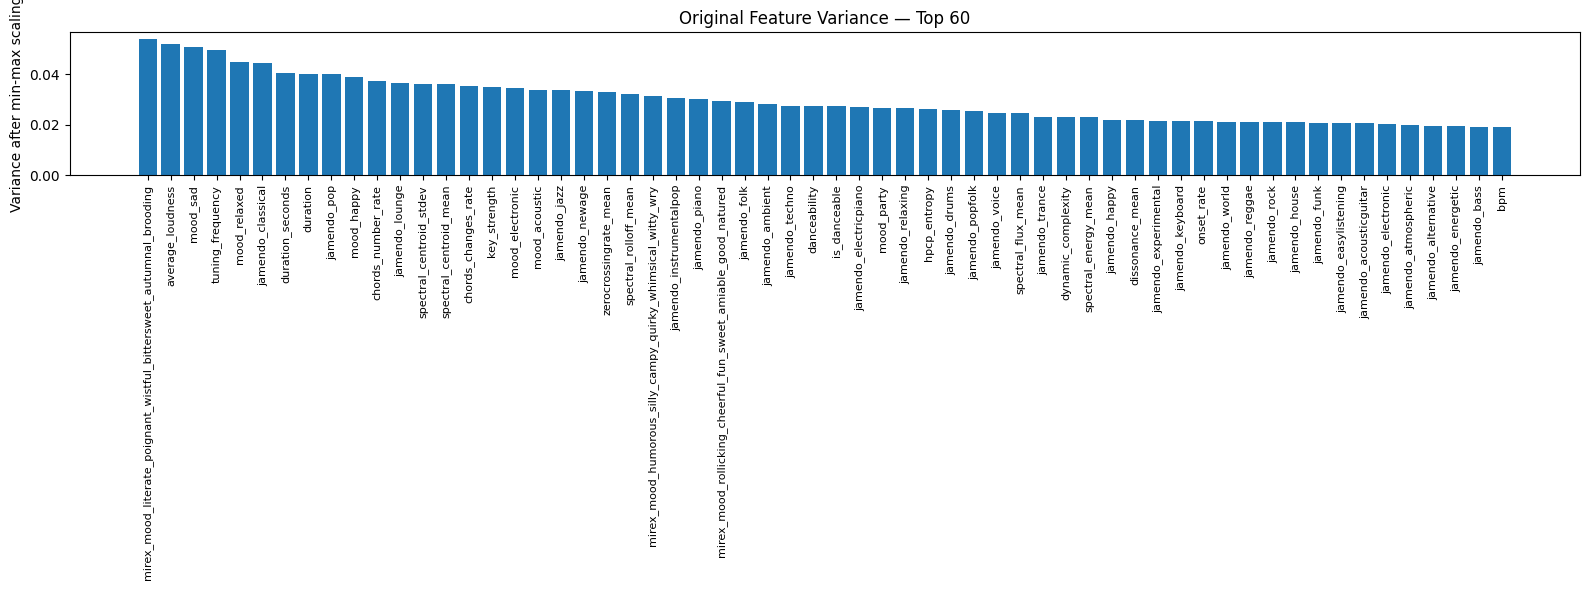

In [ ]:
# Variance after min-max scaling, following the spirit of old 02a.
feat = df_merged[AUDIO_NUMERIC_COLS].copy()
feat = feat.dropna(axis=1, how='all')
feat = feat.apply(pd.to_numeric, errors='coerce')
feat = feat.fillna(feat.mean(numeric_only=True))
feat = feat.loc[:, feat.std() > 0]

feat_scaled = (feat - feat.min()) / (feat.max() - feat.min())
variances = feat_scaled.var().sort_values(ascending=False)

print(f'Original numeric features considered: {feat.shape[1]}')
print('Top 20 by scaled variance:')
print(variances.head(20).to_string())

plt.figure(figsize=(16, 6))
top_n = min(60, len(variances))
plt.bar(range(top_n), variances.values[:top_n])
plt.xticks(range(top_n), variances.index[:top_n], rotation=90, fontsize=8)
plt.ylabel('Variance after min-max scaling')
plt.title(f'Original Feature Variance — Top {top_n}')
plt.tight_layout()
plt.show()

In [ ]:
# Correlation clustering: choose representative original columns to reduce redundancy.
# This still preserves original column meanings; it only selects a subset for the LLM prompt.
try:
    from scipy.cluster.hierarchy import linkage, fcluster
    from scipy.spatial.distance import squareform
    SCIPY_OK = True
except Exception as e:
    print('scipy unavailable; will skip clustering and use variance ranking only:', e)
    SCIPY_OK = False

CORR_THRESHOLD = 0.85  # features with |corr| >= threshold are treated as one cluster

if SCIPY_OK and feat.shape[1] >= 2:
    corr = feat.corr().fillna(0)
    dist = 1 - corr.abs()
    np.fill_diagonal(dist.values, 0)
    condensed = squareform(dist.values, checks=False)
    Z = linkage(condensed, method='average')
    cluster_ids = fcluster(Z, t=1-CORR_THRESHOLD, criterion='distance')

    clusters = defaultdict(list)
    for col, cid in zip(feat.columns, cluster_ids):
        clusters[int(cid)].append(col)

    selected_audio_features = []
    cluster_rows = []
    for cid, cols in clusters.items():
        # Representative = highest scaled variance within correlated cluster.
        rep = max(cols, key=lambda c: variances.get(c, 0))
        selected_audio_features.append(rep)
        cluster_rows.append({'cluster': cid, 'representative': rep, 'n_features': len(cols), 'members': ', '.join(cols)})

    cluster_df = pd.DataFrame(cluster_rows).sort_values(['n_features', 'representative'], ascending=[False, True])
    print(f'Correlation clusters: {len(cluster_df)}')
    display(cluster_df.head(25))
else:
    selected_audio_features = variances.index.tolist()

# Second pass: keep selected representatives covering most variance.
VARIANCE_THRESHOLD = 90  # percent; set to 100 to keep all representatives
sel_variances = variances[[f for f in selected_audio_features if f in variances.index]].sort_values(ascending=False)
cum_var_sel = sel_variances.cumsum() / sel_variances.sum() * 100
cutoff_idx = np.searchsorted(cum_var_sel.values, VARIANCE_THRESHOLD) + 1
selected_audio_features = sel_variances.index[:cutoff_idx].tolist()

SELECTED_FEATURES = CATEGORICAL_COLS + [c for c in ['year', 'decade', 'duration_seconds', 'duration'] if c in df_merged.columns] + selected_audio_features
# Deduplicate while preserving order
SELECTED_FEATURES = list(dict.fromkeys(SELECTED_FEATURES))

print(f'Variance threshold: {VARIANCE_THRESHOLD}%')
print(f'Selected original columns total: {len(SELECTED_FEATURES)}')
print(f'  Categorical/context: {len(CATEGORICAL_COLS)}')
print(f'  Numeric selected original features: {len(selected_audio_features)}')
print(SELECTED_FEATURES)

Correlation clusters: 64


,cluster,representative,n_features,members
38,13,jamendo_violin,6,"jamendo_orchestral, jamendo_soundtrack, jamend..."
27,24,jamendo_computer,4,"jamendo_downtempo, jamendo_triphop, jamendo_co..."
26,32,jamendo_house,3,"jamendo_dance, jamendo_funk, jamendo_house"
24,25,jamendo_lounge,3,"jamendo_chillout, jamendo_lounge, jamendo_elec..."
11,47,spectral_centroid_mean,3,"spectral_centroid_mean, spectral_rolloff_mean,..."
0,39,duration_seconds,2,"duration_seconds, duration"
23,19,jamendo_ambient,2,"jamendo_ambient, jamendo_atmospheric"
47,30,jamendo_drums,2,"jamendo_bass, jamendo_drums"
37,18,jamendo_newage,2,"jamendo_newage, jamendo_relaxing"
44,21,jamendo_techno,2,"jamendo_techno, jamendo_trance"


Variance threshold: 90%
Selected original columns total: 64
  Categorical/context: 9
  Numeric selected original features: 52
['title', 'orchestra', 'singer', 'style', 'album', 'filename', 'combo_key', 'key', 'scale', 'year', 'decade', 'duration_seconds', 'duration', 'mirex_mood_literate_poignant_wistful_bittersweet_autumnal_brooding', 'average_loudness', 'mood_sad', 'tuning_frequency', 'mood_relaxed', 'jamendo_classical', 'jamendo_pop', 'mood_happy', 'chords_number_rate', 'jamendo_lounge', 'spectral_centroid_stdev', 'spectral_centroid_mean', 'chords_changes_rate', 'key_strength', 'mood_electronic', 'mood_acoustic', 'jamendo_jazz', 'jamendo_newage', 'mirex_mood_humorous_silly_campy_quirky_whimsical_witty_wry', 'jamendo_instrumentalpop', 'jamendo_piano', 'mirex_mood_rollicking_cheerful_fun_sweet_amiable_good_natured', 'jamendo_folk', 'jamendo_ambient', 'jamendo_techno', 'danceability', 'is_danceable', 'mood_party', 'hpcp_entropy', 'jamendo_drums', 'jamendo_popfolk', 'jamendo_voice', 'sp

## 3. Build original-feature catalog and LLM prompt

In [ ]:
# Original-column feature catalog.
# The descriptions are for prompting the LLM; every feature name below is expected to be an existing CSV column.
# No new collapsed/derived features are introduced here.

FEATURE_CATALOG = {
    'categorical_metadata': [
        ('title', 'Track title'),
        ('orchestra', 'Orchestra name'),
        ('singer', 'Singer name if available'),
        ('style', 'Tango style: tango, vals, or milonga'),
        ('album', 'Album or source collection'),
        ('filename', 'Audio filename'),
        ('combo_key', 'Grouping key combining orchestra, singer, and style'),
        ('key', 'Estimated musical key'),
        ('scale', 'Estimated scale or mode'),
    ],
    'numeric_metadata': [
        ('year', 'Recording or release year'),
        ('decade', 'Decade bucket'),
        ('duration_seconds', 'Track duration in seconds from metadata/catalog'),
        ('duration', 'Track duration in seconds from Essentia'),
    ],
    'rhythm_tempo': [
        ('bpm', 'Beats per minute — estimated tempo'),
        ('onset_rate', 'Number of detected note/onset events per second; higher means denser rhythm'),
        ('danceability', 'Essentia danceability score'),
        ('is_danceable', 'Essentia classifier probability/score for danceability'),
    ],
    'harmony_key': [
        ('key_strength', 'Confidence/strength of the estimated musical key'),
        ('chords_changes_rate', 'Rate of chord changes; rough harmonic movement proxy'),
        ('chords_number_rate', 'Rate/quantity of detected chords'),
        ('hpcp_entropy', 'Entropy of harmonic pitch class profile; higher can indicate less tonal concentration'),
        ('tuning_frequency', 'Estimated tuning frequency'),
    ],
    'energy_dynamics': [
        ('average_loudness', 'Average loudness'),
        ('dynamic_complexity', 'Variation/complexity in loudness dynamics'),
        ('spectral_energy_mean', 'Mean spectral energy'),
    ],
    'spectral_timbre': [
        ('spectral_centroid_mean', 'Mean spectral centroid; higher often means brighter sound'),
        ('spectral_centroid_stdev', 'Variation in spectral centroid'),
        ('spectral_complexity_mean', 'Mean spectral complexity'),
        ('spectral_rolloff_mean', 'Mean rolloff frequency; higher often means brighter/more high-frequency content'),
        ('spectral_flux_mean', 'Mean spectral flux; amount of spectral change over time'),
        ('dissonance_mean', 'Mean dissonance estimate'),
        ('zerocrossingrate_mean', 'Mean zero crossing rate; related to noisiness/high-frequency activity'),
    ],
    'mirex_mood': [
        ('mirex_mood_passionate_rousing_confident_boisterous_rowdy', 'MIREX mood cluster: passionate, rousing, confident, boisterous, rowdy'),
        ('mirex_mood_rollicking_cheerful_fun_sweet_amiable_good_natured', 'MIREX mood cluster: cheerful, fun, sweet, amiable'),
        ('mirex_mood_literate_poignant_wistful_bittersweet_autumnal_brooding', 'MIREX mood cluster: poignant, wistful, bittersweet, brooding'),
        ('mirex_mood_humorous_silly_campy_quirky_whimsical_witty_wry', 'MIREX mood cluster: humorous, quirky, whimsical'),
        ('mirex_mood_aggressive_fiery_tense_anxious_intense_volatile_visceral', 'MIREX mood cluster: aggressive, fiery, tense, intense'),
    ],
    'jamendo_genre': [
        ('jamendo_alternative', 'Jamendo genre classifier: alternative'),
        ('jamendo_ambient', 'Jamendo genre classifier: ambient'),
        ('jamendo_atmospheric', 'Jamendo genre classifier: atmospheric'),
        ('jamendo_chillout', 'Jamendo genre classifier: chillout'),
        ('jamendo_classical', 'Jamendo genre classifier: classical'),
        ('jamendo_dance', 'Jamendo genre classifier: dance'),
        ('jamendo_downtempo', 'Jamendo genre classifier: downtempo'),
        ('jamendo_easylistening', 'Jamendo genre classifier: easy listening'),
        ('jamendo_electronic', 'Jamendo genre classifier: electronic'),
        ('jamendo_experimental', 'Jamendo genre classifier: experimental'),
        ('jamendo_folk', 'Jamendo genre classifier: folk'),
        ('jamendo_funk', 'Jamendo genre classifier: funk'),
        ('jamendo_hiphop', 'Jamendo genre classifier: hiphop'),
        ('jamendo_house', 'Jamendo genre classifier: house'),
        ('jamendo_indie', 'Jamendo genre classifier: indie'),
        ('jamendo_instrumentalpop', 'Jamendo genre classifier: instrumental pop'),
        ('jamendo_jazz', 'Jamendo genre classifier: jazz'),
        ('jamendo_lounge', 'Jamendo genre classifier: lounge'),
        ('jamendo_metal', 'Jamendo genre classifier: metal'),
        ('jamendo_newage', 'Jamendo genre classifier: new age'),
        ('jamendo_orchestral', 'Jamendo genre classifier: orchestral'),
        ('jamendo_pop', 'Jamendo genre classifier: pop'),
        ('jamendo_popfolk', 'Jamendo genre classifier: pop folk'),
        ('jamendo_poprock', 'Jamendo genre classifier: pop rock'),
        ('jamendo_reggae', 'Jamendo genre classifier: reggae'),
        ('jamendo_rock', 'Jamendo genre classifier: rock'),
        ('jamendo_soundtrack', 'Jamendo genre classifier: soundtrack'),
        ('jamendo_techno', 'Jamendo genre classifier: techno'),
        ('jamendo_trance', 'Jamendo genre classifier: trance'),
        ('jamendo_triphop', 'Jamendo genre classifier: triphop'),
        ('jamendo_world', 'Jamendo genre classifier: world'),
    ],
    'jamendo_instrument': [
        ('jamendo_acousticguitar', 'Jamendo instrument classifier: acoustic guitar'),
        ('jamendo_bass', 'Jamendo instrument classifier: bass'),
        ('jamendo_computer', 'Jamendo instrument classifier: computer/electronic source'),
        ('jamendo_drummachine', 'Jamendo instrument classifier: drum machine'),
        ('jamendo_drums', 'Jamendo instrument classifier: drums'),
        ('jamendo_electricguitar', 'Jamendo instrument classifier: electric guitar'),
        ('jamendo_electricpiano', 'Jamendo instrument classifier: electric piano'),
        ('jamendo_guitar', 'Jamendo instrument classifier: guitar'),
        ('jamendo_keyboard', 'Jamendo instrument classifier: keyboard'),
        ('jamendo_piano', 'Jamendo instrument classifier: piano'),
        ('jamendo_strings', 'Jamendo instrument classifier: strings'),
        ('jamendo_synthesizer', 'Jamendo instrument classifier: synthesizer'),
        ('jamendo_violin', 'Jamendo instrument classifier: violin'),
        ('jamendo_voice', 'Jamendo instrument classifier: voice'),
    ],
    'jamendo_mood_function': [
        ('jamendo_emotional', 'Jamendo mood classifier: emotional'),
        ('jamendo_energetic', 'Jamendo mood classifier: energetic'),
        ('jamendo_film', 'Jamendo tag classifier: film/cinematic'),
        ('jamendo_happy', 'Jamendo mood classifier: happy'),
        ('jamendo_relaxing', 'Jamendo mood classifier: relaxing'),
    ],
    'essentia_mood': [
        ('mood_happy', 'Essentia mood classifier: happy'),
        ('mood_sad', 'Essentia mood classifier: sad'),
        ('mood_relaxed', 'Essentia mood classifier: relaxed'),
        ('mood_aggressive', 'Essentia mood classifier: aggressive'),
        ('mood_party', 'Essentia mood classifier: party'),
        ('mood_acoustic', 'Essentia mood classifier: acoustic'),
        ('mood_electronic', 'Essentia mood classifier: electronic'),
    ],
}

ALL_FEATURE_NAMES = []
FEATURE_DESC_MAP = {}
for group, features in FEATURE_CATALOG.items():
    for fname, fdesc in features:
        ALL_FEATURE_NAMES.append(fname)
        FEATURE_DESC_MAP[fname] = fdesc

AVAILABLE_FEATURES = [f for f in ALL_FEATURE_NAMES if f in df_merged.columns]
MISSING_FEATURES = [f for f in ALL_FEATURE_NAMES if f not in df_merged.columns]
UNCATALOGUED = [c for c in df_merged.columns if c not in ALL_FEATURE_NAMES and not c.startswith('Unnamed')]

print(f'Catalog defines {len(ALL_FEATURE_NAMES)} fields across {len(FEATURE_CATALOG)} groups')
print(f'Available in df_merged: {len(AVAILABLE_FEATURES)}')
print(f'Missing from df_merged: {len(MISSING_FEATURES)}')
print(f'Uncatalogued existing columns: {UNCATALOGUED}')

Catalog defines 94 fields across 11 groups
Available in df_merged: 94
Missing from df_merged: 0
Uncatalogued existing columns: []


In [ ]:
def build_feature_description_prompt(df: pd.DataFrame, feature_catalog: dict) -> str:
    """Build the feature-description block sent to the LLM."""
    lines = []
    for group, features in feature_catalog.items():
        lines.append(f'\n### {group.upper()}')
        for fname, fdesc in features:
            if fname not in df.columns:
                continue
            col = df[fname]
            if pd.api.types.is_numeric_dtype(col):
                vals = pd.to_numeric(col, errors='coerce')
                lines.append(
                    f'- **{fname}**: {fdesc} | observed range [{vals.min():.6g}, {vals.max():.6g}], '
                    f'mean={vals.mean():.6g}, std={vals.std():.6g}'
                )
            else:
                sample_vals = col.dropna().astype(str).unique()[:8]
                lines.append(
                    f'- **{fname}**: {fdesc} | categorical, {col.nunique(dropna=True)} unique; '
                    f'examples={list(sample_vals)}'
                )
    return '\n'.join(lines)

In [ ]:
# Filter catalog to selected original columns only.
SELECTED_CATALOG = {}
for group, features in FEATURE_CATALOG.items():
    selected = [(f, d) for f, d in features if f in SELECTED_FEATURES and f in df_merged.columns]
    if selected:
        SELECTED_CATALOG[group] = selected

SELECTED_FEATURE_PROMPT = build_feature_description_prompt(df_merged, SELECTED_CATALOG)
print(f'Selected catalog groups: {list(SELECTED_CATALOG.keys())}')
print(f'Selected catalog field count: {sum(len(v) for v in SELECTED_CATALOG.values())}')
print(SELECTED_FEATURE_PROMPT[:3000])

Selected catalog groups: ['categorical_metadata', 'numeric_metadata', 'rhythm_tempo', 'harmony_key', 'energy_dynamics', 'spectral_timbre', 'mirex_mood', 'jamendo_genre', 'jamendo_instrument', 'jamendo_mood_function', 'essentia_mood']
Selected catalog field count: 64

### CATEGORICAL_METADATA
- **title**: Track title | categorical, 283 unique; examples=['Asi Me Gusta A Mi', 'Compadreando', 'En Lo de Laura', 'Entre Copa y Copa', 'Porque Me Siento Feliz', 'Con Permiso', 'El Barrio Del Tambor', 'Ropa Blanca']
- **orchestra**: Orchestra name | categorical, 16 unique; examples=["Angel D'Agostino", 'Anibal Troilo', 'Carlos Di Sarli', 'Francisco Canaro', "Juan D'Arienzo", 'Ricardo Tanturi', 'Alfredo De Angelis', 'Alfredo Gobbi']
- **singer**: Singer name if available | categorical, 25 unique; examples=['Angel Vargas', 'Alberto Marino', 'Francisco Fiorentino', 'Roberto Rufino', 'Ernesto Famá', 'Instrumental', 'Alberto Echagüe', 'Alberto Castillo']
- **style**: Tango style: tango, vals, or milon

## 4. Save artifacts for 02b/02c

In [ ]:
ARTIFACT_DIR = Path('drive/MyDrive/GenAI/proj/atdj_features_exp')
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

df_merged.to_pickle(ARTIFACT_DIR / 'df_merged.pkl')
with open(ARTIFACT_DIR / 'feature_catalog.pkl', 'wb') as f:
    pickle.dump(SELECTED_CATALOG, f)
with open(ARTIFACT_DIR / 'feature_prompt.txt', 'w', encoding='utf-8') as f:
    f.write(SELECTED_FEATURE_PROMPT)
with open(ARTIFACT_DIR / 'selected_features.json', 'w', encoding='utf-8') as f:
    json.dump(SELECTED_FEATURES, f, indent=2)

print('Saved artifacts to:', ARTIFACT_DIR)
print('Files:', [p.name for p in ARTIFACT_DIR.iterdir()])

Saved artifacts to: drive/MyDrive/GenAI/proj/atdj_features_exp
Files: ['df_merged.pkl', 'feature_catalog.pkl', 'feature_prompt.txt', 'selected_features.json']
